# Social Media Emotion Analyzer - Model Development
This notebook shows the complete process for data loading, preprocessing, classical modeling, transformer fine-tuning, and evaluation.

## 1. Data Loading and Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/emotion_clean.csv')
display(df.head())

,text,emotion,clean_text
0,That is an exceedingly rare failure. I read an...,anger,exceedingly rare failure read article about gu...
1,i feel so embarrassed,sadness,feel embarrass
2,"Dude I don’t even know what that guys deal is,...",sadness,dude don t even know what guy deal honestly fe...
3,Both. I have a feeling that broth was ruined a...,surprise,both feel broth ruin long time ago footballer ...
4,i feel incredibly selfish to say it but i was ...,anger,feel incredibly selfish say lead believe could...


In [3]:
# Check class distribution
emotion_counts = df['emotion'].value_counts()
print(emotion_counts)

emotion
anger       5000
sadness     5000
surprise    5000
fear        5000
love        4999
joy         4998
Name: count, dtype: int64


## 2. Text Preprocessing
Here we implement text cleaning directly without relying on external files.

In [4]:
import re

STOPWORDS = {"a", "am", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from", "has", "have", "he", "i", "in", "is", "it", "its", "me", "my", "of", "on", "or", "our", "she", "so", "that", "the", "their", "them", "they", "this", "to", "was", "we", "were", "with", "you", "your"}

def clean_text(text: str) -> str:
    text = "" if text is None else str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

sample = 'I am feeling so happy today!!! @friend #Joy'
print("Original:", sample)
print("Cleaned:", clean_text(sample))

# Apply to dataset
df['clean_text_notebook'] = df['text'].apply(clean_text)

Original: I am feeling so happy today!!! @friend #Joy
Cleaned: feeling happy today joy


## 3. Feature Extraction and Classical Models\n
We split the data and train TF-IDF Bigram + SVM, Count Bigram + Logistic Regression, Count Unigram + Logistic Regression, and Count Bigram + SVM.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text_notebook"],
    df["emotion"],
    test_size=0.2,
    random_state=42,
    stratify=df["emotion"]
)

label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
model_results = []

def evaluate_and_plot(y_true, y_pred, model_name):
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    model_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": p,
        "Recall": r,
        "F1-Score": f1
    })
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=label_names)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


### TF-IDF Bigram + SVM

              precision    recall  f1-score   support

       anger       0.89      0.88      0.88      1000
        fear       0.95      0.94      0.94      1000
         joy       0.92      0.88      0.90      1000
        love       0.92      0.93      0.92      1000
     sadness       0.92      0.93      0.92      1000
    surprise       0.91      0.94      0.93      1000

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000



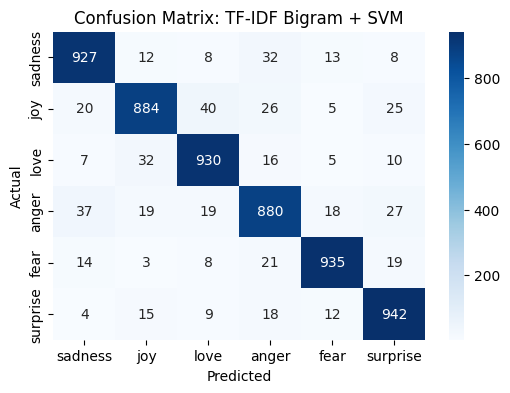

In [6]:
pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", CalibratedClassifierCV(LinearSVC(class_weight="balanced"), cv=3))
])
pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))
evaluate_and_plot(y_test, y_pred_svm, "TF-IDF Bigram + SVM")


### Count Bigram + Logistic Regression

              precision    recall  f1-score   support

       anger       0.87      0.89      0.88      1000
        fear       0.96      0.92      0.94      1000
         joy       0.91      0.86      0.88      1000
        love       0.90      0.92      0.91      1000
     sadness       0.93      0.92      0.92      1000
    surprise       0.91      0.94      0.93      1000

    accuracy                           0.91      6000
   macro avg       0.91      0.91      0.91      6000
weighted avg       0.91      0.91      0.91      6000



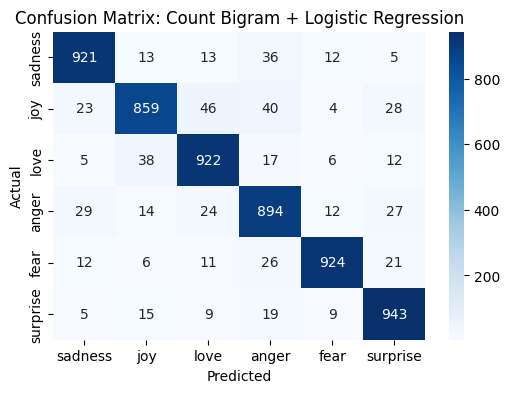

In [7]:
pipeline_lr = Pipeline([
    ("count", CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
evaluate_and_plot(y_test, y_pred_lr, "Count Bigram + Logistic Regression")


### Count Unigram + Logistic Regression

              precision    recall  f1-score   support

       anger       0.85      0.86      0.85      1000
        fear       0.93      0.90      0.92      1000
         joy       0.90      0.82      0.86      1000
        love       0.86      0.91      0.88      1000
     sadness       0.90      0.89      0.89      1000
    surprise       0.86      0.92      0.89      1000

    accuracy                           0.88      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.88      0.88      0.88      6000



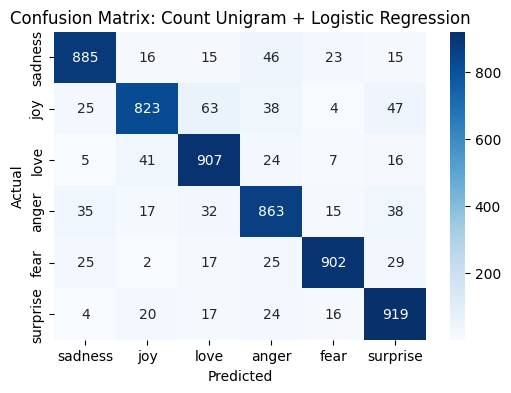

In [8]:
pipeline_lr_uni = Pipeline([
    ("count", CountVectorizer(ngram_range=(1, 1), min_df=2)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_lr_uni.fit(X_train, y_train)
y_pred_lr_uni = pipeline_lr_uni.predict(X_test)
print(classification_report(y_test, y_pred_lr_uni))
evaluate_and_plot(y_test, y_pred_lr_uni, "Count Unigram + Logistic Regression")


### Count Bigram + SVM

/home/jimmy_linux/venvs/ml_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/jimmy_linux/venvs/ml_env/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


              precision    recall  f1-score   support

       anger       0.88      0.88      0.88      1000
        fear       0.95      0.94      0.95      1000
         joy       0.92      0.87      0.89      1000
        love       0.91      0.93      0.92      1000
     sadness       0.93      0.93      0.93      1000
    surprise       0.91      0.94      0.93      1000

    accuracy                           0.92      6000
   macro avg       0.92      0.92      0.92      6000
weighted avg       0.92      0.92      0.92      6000



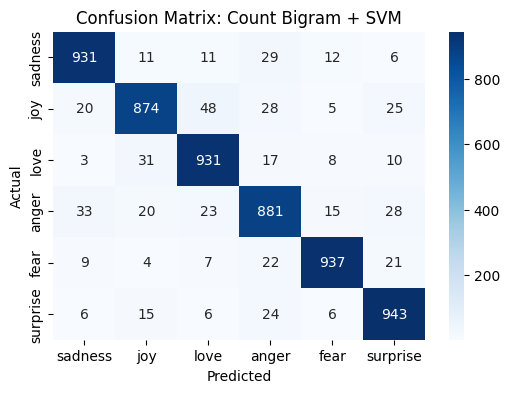

In [9]:
pipeline_rf = Pipeline([
    ("count", CountVectorizer(ngram_range=(1, 2), min_df=2)),
    ("classifier", CalibratedClassifierCV(LinearSVC(class_weight="balanced"), cv=3))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
evaluate_and_plot(y_test, y_pred_rf, "Count Bigram + SVM")


## 4. DistilBERT Bonus Model
We use huggingface transformers to fine-tune DistilBERT.

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: f1ab0693-d27d-4d0c-8dac-6eb37a5d36d1)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


Map:   0%|          | 0/23997 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_2260/3170816627.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.400000,0.408400
2,0.223200,0.329819
3,0.157400,0.329404


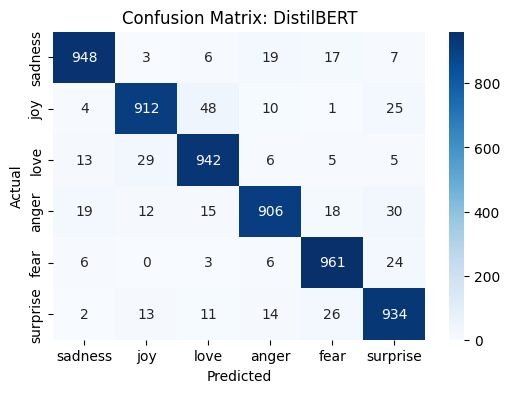

In [22]:
# Note: This requires 'transformers' and 'datasets' libraries.
import os
import numpy as np
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

label_to_id = {label: idx for idx, label in enumerate(label_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

df["label"] = df["emotion"].map(label_to_id)

train_df, eval_df = train_test_split(df[["text", "label"]], test_size=0.2, random_state=42, stratify=df["label"])
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_dataset = Dataset.from_pandas(eval_df.reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
eval_dataset = eval_dataset.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names),
    id2label=id_to_label,
    label2id=label_to_id,
)

training_args = TrainingArguments(
    output_dir="./distilbert_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
)

trainer.train() # Uncomment to run the training locally in the notebook
preds = trainer.predict(eval_dataset)
y_pred_distilbert = np.argmax(preds.predictions, axis=1)
y_pred_labels = [id_to_label[p] for p in y_pred_distilbert]
y_true_labels = [id_to_label[l] for l in eval_dataset['label']]
evaluate_and_plot(y_true_labels, y_pred_labels, "DistilBERT")


## 5. Model Comparison Table
Here we compare the performance of all trained models based on Accuracy, Precision, Recall, and F1-Score.

,Model,Accuracy,Precision,Recall,F1-Score
0,DistilBERT,0.933833,0.934110,0.933833,0.933793
1,DistilBERT,0.921167,0.921994,0.921167,0.921196
2,TF-IDF Bigram + SVM,0.916333,0.916365,0.916333,0.916247
3,Count Bigram + SVM,0.916167,0.916322,0.916167,0.916088
4,Count Bigram + Logistic Regression,0.910500,0.911030,0.910500,0.910494
5,DistilBERT,0.892333,0.893101,0.892333,0.892497
6,Count Unigram + Logistic Regression,0.883167,0.884182,0.883167,0.883111


/tmp/ipykernel_2260/3705190418.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1-Score", y="Model", data=comparison_df, palette="viridis")


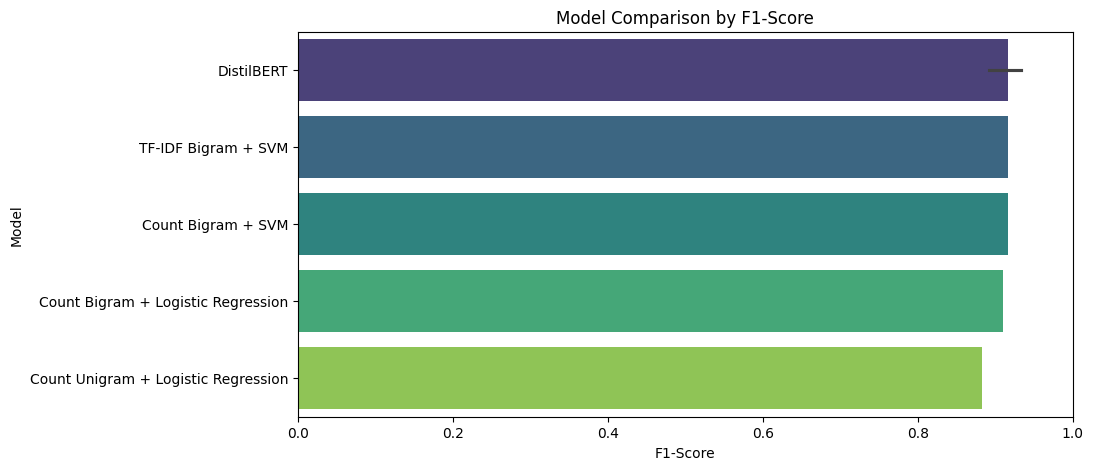

In [24]:
# Display comparison table
comparison_df = pd.DataFrame(model_results)
comparison_df = comparison_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(comparison_df)

# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x="F1-Score", y="Model", data=comparison_df, palette="viridis")
plt.title("Model Comparison by F1-Score")
plt.xlim(0, 1)
plt.show()
